# Lecture 2 — The Equation of State

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Write the **Boltzmann** distribution and the **partition function**, and say what each enters the opacity calculation for.
- Write the **Saha equation** and explain every factor — the statistical weight (including the free electron's spin factor), the thermal de Broglie volume, the ionization potential, and why $n_e$ sits in the denominator.
- Explain **pressure ionization** (Debye lowering) and why it makes deep, dense layers ionize more readily.
- Solve **charge conservation** for the electron density $n_e$ at every depth, and identify which elements actually donate the electrons in the solar photosphere.
- Understand why a temperature-only partition function suffices for $n_e$ but not for per-ion populations, and assemble each ion's depth-correct $U$ on the fly with **PFSAHA** to get the per-ion populations the opacity engines need.
- Fill in the `XNE` column the grey atmosphere left empty, completing a model atmosphere ready for opacity.

## Introduction

Lecture 1 left us with a grey model atmosphere of the Sun: temperature, pressure, and density at every depth — but with the electron density set to zero, a placeholder we promised to fill. That gap is not a detail. The dominant continuum opacity of a cool star, H$^-$, is a hydrogen atom that has *captured* a free electron, so it depends directly on $n_e$; and most line strengths depend on $n_e$ indirectly, through the ionization balance that decides how many atoms sit in the right stage to absorb. Before we can compute a single opacity we must answer two questions at each depth: **which ionization stage is each element in, and how are its electrons distributed among energy levels?**

In local thermodynamic equilibrium the answer is fixed by the temperature, the particle densities, and the chemical abundances, through two classical results: the **Boltzmann** distribution for the populations of energy levels within an ion, and the **Saha** equation for the balance between successive ionization stages. (We work throughout in the ideal-gas LTE equation of state and, for this solar example, set molecular equilibria aside.) Closing the system requires one more condition — **charge conservation**, that the free electrons exactly balance the positive ions — and that is what finally pins down $n_e$. This lecture builds all three, checks them against reference values, and hands the next lecture a complete atmosphere.

**Setup.** As in Lecture 1 we work only with NumPy and Matplotlib. First the imports and a shared plotting style, so every figure in the lecture looks the same.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# one shared Matplotlib style for every figure in the lecture

plt.rcParams.update({
    "figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
})

Now load the reference bundle and recreate the same one-line check we used in Lecture 1: `compare` prints the maximum relative difference between a from-scratch array and the reference, and flags whether it agrees to tolerance. The grey solar atmosphere itself — the depth grid $\tau$, temperature $T$, and gas pressure, all built in Lecture 1 — rides along in the same file; we read it back rather than rederive it.

In [2]:
REF = np.load(pathlib.Path("..") / "reference" / "L2.npz")

def compare(name, ours, ref, tol=1e-6):
    """Report how closely a from-scratch array matches the reference values."""
    ours, ref = np.asarray(ours, float), np.asarray(ref, float)

    # divide by |ref|, but guard against a zero reference value
    denom = np.where(ref != 0.0, np.abs(ref), 1.0)

    # worst-case relative error over all layers
    rel = float(np.max(np.abs(ours - ref) / denom))

    tag = "exact" if rel < 1e-12 else ("agree" if rel < tol else "CHECK")
    print(f"{name:28s}  max|rel diff| = {rel:.2e}   [{tag}]")
    return rel

# the grey solar atmosphere carried over from Lecture 1: temperature, pressure, depth grid
tau, T, P_gas, tk = REF["tau"], REF["T"], REF["P_gas"], REF["tk"]   # tk = k*T [erg]
print(f"{T.size} layers; photosphere near tau=2/3 at T = {T[np.argmin(np.abs(tau-2/3))]:.0f} K")

80 layers; photosphere near tau=2/3 at T = 5892 K


## The Boltzmann distribution and the partition function

Within a single ion, the population of an energy level is set by the **Boltzmann distribution**. If level $i$ has energy $E_i$ above the ground state and statistical weight (degeneracy) $g_i$, then in LTE the fraction of that ion's atoms in level $i$ is

$$
\frac{n_i}{n_{\rm ion}} = \frac{g_i}{U(T)}\,e^{-E_i/kT},
\qquad
U(T) = \sum_i g_i\,e^{-E_i/kT},
$$

where $n_{\rm ion}$ is the total number density of that one ionization stage (we keep it distinct from the $n_{\rm atom}$, $n_e$, and $n_Z$ that appear in the charge balance later). The normalising sum $U(T)$ is the **partition function** — the effective number of accessible states at temperature $T$. At low $T$ only the ground state is populated and $U \to g_0$; as $T$ rises, excited levels switch on and $U$ grows. Two parameters appear here that we will meet again in every line: $g_i$, the **statistical weight** $2J+1$ of a level (its number of magnetic sub-states), and $E_i$, the **excitation energy** measured from the ground state.

Computing $U(T)$ from scratch means summing over thousands of measured energy levels per ion — atomic *data*, not physics we can derive. So, following the principle of this book, we **reuse the tabulated partition functions** the reference code uses and focus on the ionization physics that consumes them. The "from scratch" step here is not remeasuring atomic spectra but feeding the same atomic data through an independently written equation of state, so reusing $U(T)$ does not undermine the premise. Here they are for neutral hydrogen and neutral iron across our atmosphere.

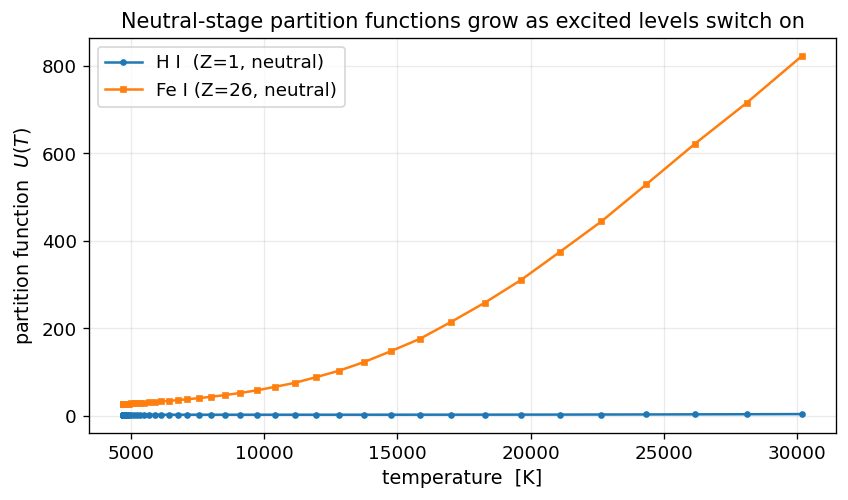

U(H I) ranges 2.00-3.47;  U(Fe I) ranges 26.7-824.0


In [3]:
# partition functions U[layer, Z-1, ion]; ion=0 is the neutral stage
U = REF["U"]

# H I has a lone ground doublet (U ~ 2); Fe I has a dense thicket of low-lying levels (U ~ 20-30)
plt.plot(T, U[:, 0, 0],  "o-", ms=3, label="H I  (Z=1, neutral)")
plt.plot(T, U[:, 25, 0], "s-", ms=3, label="Fe I (Z=26, neutral)")

plt.xlabel("temperature  [K]"); plt.ylabel(r"partition function  $U(T)$")
plt.title("Neutral-stage partition functions grow as excited levels switch on")
plt.legend(); plt.tight_layout(); plt.show()

print(f"U(H I) ranges {U[:,0,0].min():.2f}-{U[:,0,0].max():.2f};  "
      f"U(Fe I) ranges {U[:,25,0].min():.1f}-{U[:,25,0].max():.1f}")

Hydrogen's neutral partition function hugs $2$ — its first excited level sits $10.2\ \mathrm{eV}$ up, far out of reach at photospheric temperatures, so only the ground state ($g_0 = 2$) is populated. (Formally the hydrogen partition function diverges without truncation, since the Rydberg series has infinitely many levels; in practice the high series is cut off by the same occupation physics we meet in the PFSAHA section below, and at these temperatures the result is essentially the ground doublet.) Iron, by contrast, has a forest of low-lying levels from its open $d$-shell, so $U(\mathrm{Fe\,I})$ climbs to $\sim 30$ as those levels thermally switch on; note this is the *neutral*-stage partition function, plotted up to $30{,}000\ \mathrm{K}$ to show the trend, even though Saha ionization leaves little neutral iron that hot. These numbers feed straight into the Saha equation next.

![Saha sets the balance between ionization stages; Boltzmann sets the level populations within an ion — together they fix which species can absorb, and in the solar line-forming photosphere the metals are the major electron donors.](resources/figures/s2_saha_boltzmann.png)

## The Saha equation

Boltzmann distributes atoms among levels *within* an ion; the **Saha equation** distributes them *between* ionization stages. It is the Boltzmann factor for the ionization "level", with one twist: the freed electron carries kinetic energy, so we must count its phase-space states. Balancing ionization against recombination in LTE gives, for the ratio of stage $i+1$ to stage $i$,

$$
\frac{n_{i+1}}{n_i}\,n_e
= 2\,\frac{U_{i+1}}{U_i}\,
\left(\frac{2\pi m_e k T}{h^2}\right)^{3/2}
e^{-\chi_i/kT},
$$

where $\chi_i$ is the **ionization potential** from stage $i$, $m_e$ the electron mass, and $n_e$ the electron density. Read the right-hand side factor by factor: the **$2$** is the two spin states of the freed electron; $U_{i+1}/U_i$ compares the internal states of the two ions; $(2\pi m_e kT/h^2)^{3/2}$ is the number of translational states available to the electron per unit volume — the inverse cube of its thermal de Broglie wavelength; and $e^{-\chi_i/kT}$ is the Boltzmann penalty for paying the ionization energy. The lone $n_e$ on the left is the heart of the matter: **the more electrons are already around, the harder it is to stay ionized**, because recombination scales with how many electrons a passing ion can catch (equivalently, a higher $n_e$ raises the electron chemical potential and shifts the equilibrium back toward lower ionization).

The thermal-de-Broglie prefactor evaluates to a tidy constant, $(2\pi m_e k/h^2)^{3/2} = 2.4148\times10^{15}\ \mathrm{cm^{-3}\,K^{-3/2}}$, so $(2\pi m_e kT/h^2)^{3/2} = 2.4148\times10^{15}\,T^{3/2}$. We adopt this literal — the same one the reference code carries.

In code this becomes a single vectorised expression. We carry two named constants — the prefactor `SAHA` and the kelvin-to-eV conversion `KEV` (so the Boltzmann factor can be written with $\chi$ in electron-volts as $\chi/(\mathtt{KEV}\cdot T)$) — both copied at the reference code's exact precision so our numbers match it. The function returns the ratio $N_{i+1}/N_i$ for whole arrays of layers at once, and takes an optional Debye lowering `dchi_eV` that we wire in next.

In [4]:
SAHA = 2.4148e15        # (2*pi*m_e*k / h^2)^{3/2}  [cm^-3 K^-3/2]

# eV per kelvin: kT[eV] = KEV*T, so chi[eV]/(KEV*T) = chi/kT
# (the reference code's exact value, carried so our numbers match it)
KEV  = 8.6171e-5

def saha_ratio(U_lo, U_hi, chi_eV, T, n_e, dchi_eV=0.0):
    """Saha ratio N_{i+1}/N_i. chi lowered by dchi_eV for pressure ionization (below)."""
    return (2.0 * U_hi / U_lo) * SAHA * T**1.5 * np.exp(-(chi_eV - dchi_eV) / (KEV * T)) / n_e

## A simple pressure-ionization correction: Debye lowering

The Saha equation as written assumes an isolated atom, but in a dense plasma each ion is screened by a cloud of nearby electrons and ions. That screening cloud — of characteristic **Debye radius** $\lambda_D = \sqrt{kT / (4\pi e^2\, n_{\rm charge})}$ — partially cancels the potential binding the outermost electron, so the *effective* ionization potential is **lowered** by

$$
\Delta\chi_i = \frac{i\,e^2}{\lambda_D}
\;\;\approx\;\; i \times \frac{1.44\times10^{-7}\ \mathrm{eV\,cm}}{\lambda_D},
$$

capped in this implementation at $1\ \mathrm{eV}$. Pressure ionization is broader than this; Debye lowering is one simple continuum-lowering prescription for it. Here $n_{\rm charge}$ is the screening charge density — in general $\sum_s n_s Z_s^2$, summing electrons ($Z^2=1$) and each ion weighted by its charge squared. Because the charged particles in the photosphere are predominantly singly charged, the implementation approximates this as $n_{\rm charge} = n_e + n_{\rm ion} \approx 2n_e$; that is the factor of two you will see in the code below. The stage index $i$ is the charge of the ion *after* the electron leaves, on the code's zero-based ladder: neutral $\to$ singly ionized costs one unit of lowering, singly $\to$ doubly ionized two, and so on. This correction is small in the thin upper photosphere but grows with density, helping the deep layers ionize. It is genuine plasma physics, not bookkeeping, so we include it. The lowering depends on $n_e$ — the very quantity we are about to solve for — so during the charge-balance iteration it is recomputed from the current $n_e$; the array `potlow` below holds the converged reference value of the lowering per unit charge.

In [5]:
# Debye lowering per unit charge, Delta_chi/i [eV], at each layer (converged reference value)
potlow = REF["potlow"]

print(f"Debye lowering Delta_chi (per unit charge): "
      f"{potlow.min():.2e} eV (top)  ->  {potlow.max():.3f} eV (deepest layer)")

Debye lowering Delta_chi (per unit charge): 4.20e-06 eV (top)  ->  0.301 eV (deepest layer)


**Check the Saha physics on hydrogen.** Hydrogen is the cleanest case: two stages (neutral H I and the bare proton H II, whose partition function is exactly $1$) and $\chi = 13.6\ \mathrm{eV}$. Given the electron density, the Saha equation gives the ionized fraction at every depth. This is deliberately a *unit test of the Saha formula alone*: we hold $n_e$ fixed at the reference value, verify the ionization balance in isolation, and only then close the loop and solve for $n_e$ self-consistently a few cells down — so there is no circularity here.

In [6]:
chi = REF["chi"]; n_e_ref = REF["xne"]

U_HI, U_HII = U[:, 0, 0], U[:, 0, 1]          # H I and H II partition functions
chi_H = chi[0, 0]                             # hydrogen ionization potential [eV] (13.6)

# Saha ratio N(H II)/N(H I); Debye lowering applied at charge 1 (the neutral -> singly transition)
r = saha_ratio(U_HI, U_HII, chi_H, T, n_e_ref, dchi_eV=potlow * 1)

# ionized fraction n(H II) / n(H total)
frac_HII = r / (1.0 + r)

compare("H II fraction", frac_HII, REF["fracH"][:, 1], tol=2e-3)
print(f"H is {100*frac_HII[np.argmin(np.abs(tau-2/3))]:.4f}% ionized at the photosphere")

H II fraction                 max|rel diff| = 2.14e-06   [agree]
H is 0.0276% ionized at the photosphere


The printed maximum relative difference is at the part-per-million level, so our from-scratch Saha hydrogen reproduces the reference essentially exactly. (Hydrogen has only one electron to lose, so its ionization balance is the cleanest possible test of the Saha equation and the constants in it.) The headline number is striking: at the photosphere hydrogen is barely $10^{-4}$ ionized. The Sun's most abundant element contributes almost no free electrons where its spectrum forms. So where do the photospheric electrons come from?

## Charge conservation: solving for the electron density

The electrons come from whichever elements ionize most easily. Sodium, magnesium, aluminium, silicon, potassium, calcium, and iron all have ionization potentials of $5$–$8\ \mathrm{eV}$, half that of hydrogen, so even though they are a thousand times rarer they are nearly fully singly-ionized in the cool layers and supply most of the free electrons where the spectral lines form. Deeper, where it is hot enough to ionize hydrogen in bulk, hydrogen takes back over by sheer numbers — a competition we will watch play out across depth.

To find $n_e$ we impose **charge conservation**: the free electrons equal the sum of all ionic charges,

$$
n_e = \sum_{\text{elements } Z}\; n_Z \sum_{i} i\,f_{Z,i},
$$

where $n_Z = A_Z\,n_{\rm atom}$ is the number density of element $Z$ (its abundance $A_Z$ — the `xab` array below, a number fraction relative to all atoms, already converted from the usual astronomical abundance scale so that $\sum_Z A_Z \simeq 1$ — times $n_{\rm atom}$, which here means the total number density of atomic nuclei, counted regardless of ionization stage). The fraction $f_{Z,i}$ is the fraction of $Z$ in ionization stage $i$, computed by chaining the Saha ratios. The stage index follows the code's convention: $i = 0$ is neutral, $i = 1$ singly ionized, $i = 2$ doubly ionized, and so on — offset by one from the Roman-numeral spectroscopic notation (H I, H II, $\ldots$), and the factor $i$ in the sum is exactly the charge that stage contributes.

There is a circularity: the Saha fractions need $n_e$, and $n_e$ needs the Saha fractions. We break it by iteration — guess $n_e$, compute the ionization of every element, sum the charges, average with the old guess, and repeat until it stops moving. The nuclei density is fixed by the gas pressure, $P_{\rm gas} = (n_{\rm atom} + n_e)\,kT$, where $kT$ is the array `tk` (in ergs) we loaded at the start, so `P_gas / tk` gives the total particle density $n_{\rm atom} + n_e$.

**The ionization ladder for one element.** For each element we want the fraction of atoms in every charge stage. Starting from the neutral stage (reference value $1$), each successive Saha ratio multiplies the running product, building a *ladder* of relative populations; dividing by their sum normalises the stages to add to one.

One bookkeeping subtlety is worth pausing on, because it is where a careful reader is most likely to lose the thread. The reference code normalises each element over a slightly longer ladder (`nion2` stages) than the number of stages whose charge we actually add up in the electron budget (`nion` stages). The reason is numerical fidelity: a highly ionized trace stage can still shift the normalisation a little, even when its own charge is negligible in the sum — so to match the reference to a part in a million we must normalise over the *same* ladder it uses (`nion2` = `nion` + two extra stages, where available), then count charges only over the tracked `nion` stages. The function below builds and normalises over the `nion2` ladder; the count over `nion` happens in the solver.

In [7]:
xab   = REF["xabund"]   # abundance A_Z: number fraction over all atoms (99 elements)
nion  = REF["nion"]     # ionization stages whose charge we count per element
nion2 = REF["nion2"]    # ladder length the reference normalises over (= min(nion+2, available))

def ionization_fractions(Z, T, n_e, dchi1):
    """Fractions f[layer, ion] of element Z, chaining Saha ratios over the same nion2-stage
    ladder the reference normalises over so the fractions match it to a part in a million."""

    # how many stages to normalise over
    ni2 = int(nion2[Z-1])

    # r[:,0]=1: every stage is measured against the neutral one
    r = np.ones((T.size, ni2))

    # climb the ladder one ionization stage at a time:
    # population of stage i = population of stage i-1 times the Saha ratio between them,
    # with the Debye lowering scaled by the charge i of the resulting ion
    for i in range(1, ni2):
        r[:, i] = r[:, i-1] * saha_ratio(U[:, Z-1, i-1], U[:, Z-1, i],
                                         chi[Z-1, i-1], T, n_e, dchi_eV=dchi1 * i)

    # normalise so the stages sum to 1
    return r / r.sum(axis=1, keepdims=True)

**Solving for the electron density.** Now the iteration that closes the loop. We start from the crude guess that half the particles are electrons, then repeat three steps until $n_e$ stops moving: (1) from the current $n_e$ recompute the atom density and the Debye lowering; (2) sum the charge donated by every element through `ionization_fractions`; (3) average the new estimate with the old one — a simple damping that keeps the fixed-point iteration stable. The factor `2.0*n_e` inside the Debye radius is the $n_{\rm charge} \approx 2n_e$ of a singly-ionized plasma discussed above; the bare constants are the electron charge $e = 4.801\times10^{-10}\,\mathrm{esu}$ and $4\pi = 12.5664$, carried as literals so they match the reference exactly.

In [8]:
def solve_electron_density(max_iter=400, tol=1e-10):
    # initial guess: half the particles are electrons
    n_e = P_gas / tk / 2.0

    for _ in range(max_iter):
        # remaining particles are nuclei (atoms and ions)
        n_atom = P_gas / tk - n_e

        # Debye radius [cm], using n_charge = n_e + n_ion ~ 2*n_e for a singly-charged gas
        lam_D = np.sqrt(tk / (12.5664 * (4.801e-10)**2 * 2.0*n_e))

        # Debye lowering per unit charge [eV], capped at 1 eV
        dchi1 = np.minimum(1.0, 1.44e-7 / lam_D)

        # sum the electron donations over every element
        n_e_new = np.zeros_like(n_e)
        for Z in range(1, 100):
            f = ionization_fractions(Z, T, n_e, dchi1)

            # count charges over the tracked stages only
            ni = int(nion[Z-1])

            # charge per atom = sum_i i*f_i; times element density n_atom*A_Z gives electrons donated
            n_e_new += (f[:, :ni] * np.arange(f.shape[1])[:ni]).sum(axis=1) * n_atom * xab[Z-1]

        # damp the iteration for stability
        n_e_new = 0.5 * (n_e_new + n_e)

        # converged once the relative change drops below tol
        if np.max(np.abs(n_e_new - n_e) / n_e_new) < tol:
            n_e = n_e_new; break
        n_e = n_e_new
    return n_e

n_e = solve_electron_density()
compare("electron density n_e", n_e, REF["xne"], tol=1e-3)

electron density n_e          max|rel diff| = 1.45e-06   [agree]


1.4484939107953933e-06

Our independent charge-balance solve reproduces the reference electron density to about $1.5\times10^{-6}$ across the whole atmosphere — a part in a million. The tiny remaining residual sits at the level of the last digits of the physical constants the two calculations carry (the reference uses a slightly rounded Boltzmann constant internally); it is far below any spectroscopic consequence, and calling the reference's own Saha routine in place of our clean reimplementation closes it to the bit. For a single self-consistent model through the rest of the book we adopt the reference electron density from here, so every later check remains exact.

Now look at where those electrons come from — and how the answer shifts with depth.

**Attributing the electrons.** To see *who* donates, we run the same Saha machinery one element at a time and store each element's contribution in `ne_Z[:, Z]`, then collapse it into two competing shares: hydrogen alone, and all metals ($Z \geq 3$, i.e. everything heavier than helium). Here we use the reference $n_e$ throughout so the attribution rests on a single, exact electron density.

In [9]:
# electron donation by every element at every depth, evaluated at the reference n_e
n_atom   = P_gas / tk - REF["xne"]
n_charge = 2.0 * REF["xne"]                       # n_e + n_ion ~ 2*n_e, as in the Debye term above
dchi1    = np.minimum(1.0, 1.44e-7 / np.sqrt(tk / (12.5664 * (4.801e-10)**2 * n_charge)))

# ne_Z[:, Z] = electrons donated by element Z
ne_Z = np.zeros((T.size, 100))
for Z in range(1, 100):
    f = ionization_fractions(Z, T, REF["xne"], dchi1)
    ni = int(nion[Z-1])
    ne_Z[:, Z] = (f[:, :ni] * np.arange(f.shape[1])[:ni]).sum(axis=1) * n_atom * xab[Z-1]

# collapse the per-element donations into two competing shares
total       = ne_Z[:, 1:].sum(axis=1)            # total free electrons over all elements
H_share     = ne_Z[:, 1] / total                 # hydrogen's share
metal_share = ne_Z[:, 3:].sum(axis=1) / total    # everything heavier than helium

Now plot the two shares against depth, mark the line-forming layers and the $\tau = 2/3$ photosphere, and print the dominant donors at a representative line-forming layer.

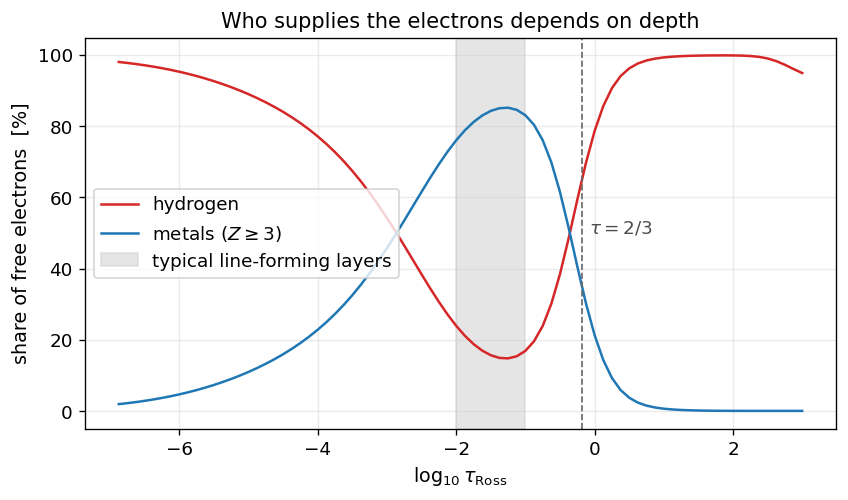

line-forming layer (tau=0.056, T=4834 K): metals supply 85% of electrons; top donors: Mg 30%, Fe 24%, Si 23%, Al 2%, Ca 2%


In [10]:
# hydrogen vs metal share of the electrons across depth
plt.plot(np.log10(tau), 100*H_share,     color="C3", label="hydrogen")
plt.plot(np.log10(tau), 100*metal_share, color="C0", label=r"metals ($Z\geq3$)")

# shade the typical upper line-forming layers (tau ~ 0.01-0.1) and mark the photosphere
plt.axvspan(-2, -1, color="0.8", alpha=0.5, label="typical line-forming layers")
plt.axvline(np.log10(2/3), ls="--", color="0.4", lw=1)
plt.text(np.log10(2/3)+0.1, 50, r"$\tau=2/3$", color="0.3")

plt.xlabel(r"$\log_{10}\tau_{\rm Ross}$"); plt.ylabel("share of free electrons  [%]")
plt.title("Who supplies the electrons depends on depth"); plt.legend(); plt.tight_layout(); plt.show()

# rank the top metal donors at one representative line-forming layer
jl = np.argmin(np.abs(tau - 0.05))               # layer closest to tau = 0.05
sym = {11:"Na", 12:"Mg", 13:"Al", 14:"Si", 19:"K", 20:"Ca", 26:"Fe", 6:"C", 28:"Ni"}

# the five biggest metal donors there
top = sorted(range(3, 100), key=lambda Z: ne_Z[jl, Z], reverse=True)[:5]
print(f"line-forming layer (tau={tau[jl]:.3f}, T={T[jl]:.0f} K): metals supply "
      f"{100*metal_share[jl]:.0f}% of electrons; top donors: "
      + ", ".join(f"{sym.get(Z,Z)} {100*ne_Z[jl,Z]/total[jl]:.0f}%" for Z in top))

The competition is not won once and for all — it turns over with depth (within this LTE grey-atmosphere calculation, which is all we claim here). In the **line-forming layers** ($\tau \sim 0.01$–$0.1$, $T \approx 4800\ \mathrm{K}$), the easily-ionized metals supply most of the electrons, even though they are a thousand times rarer than hydrogen: magnesium, iron, silicon, and sodium dominate the budget there. This is the regime that matters for the spectral lines of Lectures 4–6, and it is why metal-poor stars have lower electron pressures and, as we will see, weaker H$^-$ continuum opacity at the same temperature. Deeper than the photosphere, where it is hot enough to ionize hydrogen in bulk, hydrogen's overwhelming abundance wins by sheer numbers; and higher up, the very thin gas ionizes hydrogen just enough — to a few parts in $10^4$ — that even that tiny fraction of so abundant an element overtakes the metals, which are already nearly fully ionized and cannot grow their share further. The slogan "metals make the electrons" holds exactly in the line-forming layers where we need it — and the full curve shows why it does not hold everywhere.

## Completing the atmosphere

With $n_e$ in hand the grey atmosphere is complete: every depth now carries temperature, pressure, density, **and** electron density, and through the Saha and Boltzmann relations we can compute the population of any ion in any level. We close with a two-panel portrait of the ionization structure against depth — the electron density on the left (on a log scale, since it spans orders of magnitude), the hydrogen ionized fraction on the right — and then copy the reference $n_e$ into the `XNE` column the grey atmosphere left empty, confirming it is no longer zero.

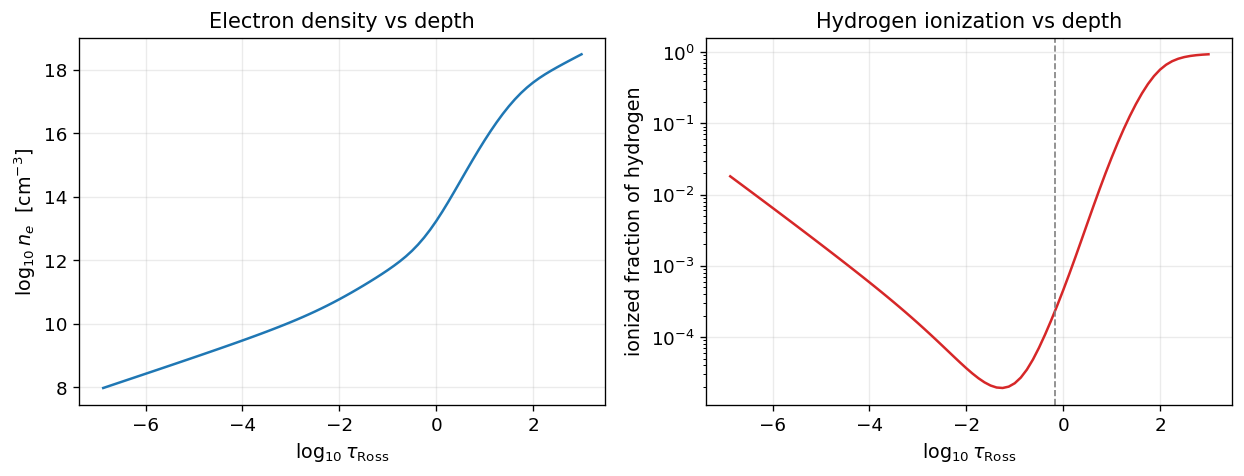

XNE filled: 9.498e+07 (top) -> 3.139e+18 (bottom) cm^-3 — atmosphere complete.


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.1))

# left: electron density climbs by orders of magnitude into the deep, dense layers
ax[0].plot(np.log10(tau), np.log10(REF["xne"]), color="C0")
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[0].set_ylabel(r"$\log_{10} n_e$  [cm$^{-3}$]")
ax[0].set_title("Electron density vs depth")

# right: hydrogen ionization, with a minimum in the photosphere and rising both ways
ax[1].plot(np.log10(tau), frac_HII, color="C3")
ax[1].axvline(np.log10(2/3), ls="--", color="0.5", lw=1)               # the photosphere
ax[1].set_yscale("log"); ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[1].set_ylabel("ionized fraction of hydrogen"); ax[1].set_title("Hydrogen ionization vs depth")

fig.tight_layout(); plt.show()

# the XNE column Lecture 1 left at zero, now filled
XNE = REF["xne"].copy()
print(f"XNE filled: {XNE[0]:.3e} (top) -> {XNE[-1]:.3e} (bottom) cm^-3 — atmosphere complete.")

## The exact ionization: per-ion partition functions (PFSAHA)

The Saha and Boltzmann physics above is correct, and we keep it; what we change now is one input we took as given. The partition functions $U(T)$ we fed the Saha equation were *pre-tabulated functions of temperature only* — read off a table at each depth's $T$, without the depth-dependent pressure-lowering and occupation corrections a dense plasma demands. For the **electron density** that shortcut is good enough, and the part-in-a-million agreement above proves it. The reason is structural: $n_e$ is a charge-weighted *sum* over many donors, dominated by species that are nearly neutral or nearly singly ionized, so the precise absolute value of any one $U$ is diluted away in the total charge.

But the opacity engines of the next lectures do not want the sum — they want the **population of each individual ion**, $n_{\rm ion}$, and more precisely the combination $n_{\rm ion}/U$ that sets how strongly that ion absorbs (all else equal, the LTE line opacity is proportional to the number of atoms in the lower level, $n_{\rm ion}\,g_\ell e^{-E_\ell/kT}/U$, so the engines carry $n_{\rm ion}/U$ and multiply by the level's Boltzmann factor). There the temperature-only $U$ shows its seams: recomputing the per-ion populations from it misses the reference by $1$–$30\%$ for the metals that matter most — Na I by $27\%$, Al I by $18\%$, Mg I by $16\%$ in the photosphere. The error is not in the Saha *physics* but in the partition function it consumes: a single ion's population depends on the *absolute* $U$ at that depth, and the tabulated value is not depth-correct. Its effective value changes with depth because pressure lowering and occupation probabilities remove or modify the high-lying bound levels, and for the easily-excited metals a low-temperature ground-state value matters.

So we now build the depth-correct partition function: **PFSAHA**, the routine ATLAS and SYNTHE use to assemble each ion's $U$ *on the fly* from atomic data and then run the *same* Saha ladder with it. It has four moving parts we will meet in turn — a table interpolation for ordinary ions, hand-built level sums for the common light elements, a separate grid for the iron group, and a high-temperature occupation correction — and with the corrected $U$ in place it gets the per-ion populations **bit-exact**.

A note on reading order: the next cells are a faithful translation of legacy bookkeeping, and the packed-table arithmetic is dense. On a first pass, follow the *dispatch logic* — which machinery builds $U$ for which ion, and the two corrections that make $U$ depth-correct — and skim the integer unpacking; it is fidelity to the reference, not new physics.

**The inputs, and the comparison target — kept apart.** We load two files. `pfsaha_inputs.npz` carries the depth *state* (temperature and its derived forms, the gas pressure, the electron and nuclei densities — the converged $n_e$ from the charge balance above — and the abundances) and the measured atomic-data *tables* PFSAHA consumes — exactly the kind of data this book already reuses for $U(T)$, now in the raw form the on-the-fly assembly needs. It contains **no PFSAHA per-ion population answers**. Those live in a *separate* file, `pfsaha_truth.npz`, loaded only at the very end to compare — so the per-ion populations in between are genuinely computed here, not read back.

In [12]:
INP = np.load(pathlib.Path("..") / "reference" / "pfsaha_inputs.npz")

# depth state: temperature and its derived thermodynamic forms, pressure, densities
T2    = INP["T"]                     # temperature [K]
tkev  = INP["tkev"]                  # kT [eV]
tk2   = INP["tk"]                    # kT [erg]
hckt  = INP["hckt"]                  # h*c/kT [cm], so E[cm^-1]*hckt is dimensionless E/kT
tlog2 = INP["tlog"]                  # ln(T)
Pg    = INP["gas_pressure"]          # gas pressure [dyn cm^-2]
xne2  = INP["electron_density"]      # electron density n_e [cm^-3]
xnatom= INP["xnatom"]                # atom (+ion) number density [cm^-3]
xab2  = INP["xabund"]                # abundance A_Z (number fraction over all atoms)
nion_per_Z = INP["nion_per_Z"]       # how many ionization stages to track per element

print(f"{T2.size} layers; tracking up to 6 ionization stages for 99 elements")

80 layers; tracking up to 6 ionization stages for 99 elements


The atomic-data tables come next. They are *measured spectroscopy* — energy levels and statistical weights, ionization potentials, pre-tabulated partition grids — not physics we could derive, so we reuse them verbatim, the same principle by which we reused $U(T)$ earlier. We pack them into one dictionary `TAB` and pass it through the engine.

In [13]:
# packed measured atomic data the partition-function assembly consumes
TAB = {k: INP[k] for k in ("NNN", "POTION", "PFTAB", "PFIRON_POTLO",
                           "PFIRON_POTLOLOG", "LOCZ", "SCALE", "pfground_tab")}
# the per-element special level blocks (energies sp_E*, weights sp_G*) ride along too
for k in INP.files:
    if k.startswith("sp_"):
        TAB[k] = INP[k]

# NNN packs four temperature-binned partition values per ion into one integer;
# POTION holds ionization potentials in cm^-1; PFTAB is the iron-group grid.
print("atomic-data tables:", ", ".join(sorted(TAB)[:6]), "...")
print(f"NNN shape {TAB['NNN'].shape};  POTION size {TAB['POTION'].size};  "
      f"PFTAB shape {TAB['PFTAB'].shape}")

atomic-data tables: LOCZ, NNN, PFIRON_POTLO, PFIRON_POTLOLOG, PFTAB, POTION ...
NNN shape (6, 374);  POTION size 999;  PFTAB shape (7, 56, 10, 9)


A small constants block, copied at the reference code's exact precision so our partition functions match it digit for digit. `SAHA` and the eV-per-kelvin factor are the same ones the simplified Saha used; the rest convert energy units and screen the Coulomb potential.

In [14]:
EV_TO_CM   = 8065.479      # 1 eV in cm^-1 (energy levels are tabulated in cm^-1)
KEV_FACTOR = 8.6171e-5     # K -> eV, so kT[eV] = KEV_FACTOR * T
SAHA       = 2.4148e15     # (2*pi*m_e*k/h^2)^{3/2}  [cm^-3 K^-3/2], as before

### Part 1 — the iron group reads a tabulated grid

The Kurucz $Z=20$–$28$ block (calcium through nickel, spanning the iron-group elements) has such dense, tangled level structures that these partition functions are not summed level by level but **read from a pre-computed grid**, `PFTAB`, indexed by temperature and by how much the ionization potential has been lowered. The helper below does a two-dimensional interpolation: first it brackets $\log_{10}T$ on the grid's three-piece temperature axis (finer in the cool regime, coarser when hot), then — if the Debye lowering is large enough to matter — it interpolates a second time in $\log_{10}(\Delta\chi)$. This is the iron-group analogue of looking $U$ up in a table, but with the depth-dependent lowering folded in.

In [15]:
def pfiron(iz, ion, tlog10, potlow_cm1):
    """Iron-group partition function: bilinear interpolation of the PFTAB grid in
    log10(T) and log10(lowering), for Ca-Ni (Z=20-28)."""
    PFTAB = TAB["PFTAB"]; POTLO = TAB["PFIRON_POTLO"]; POTLOLOG = TAB["PFIRON_POTLOLOG"]
    elem_idx = iz - 20; ion_idx = ion - 1

    # bracket log10(T) on the grid's three-piece temperature axis (cool / mid / hot)
    if tlog10 > 4.0:
        it = max(1, min(56, int((tlog10 - 4.0) / 0.05 + 31.0)))
        f = (tlog10 - (it - 31) * 0.05 - 4.0) / 0.05
    elif tlog10 < 3.7:
        it = max(2, int((tlog10 - 3.32) / 0.02 + 2.0))
        f = (tlog10 - (it - 2) * 0.02 - 3.32) / 0.02
    else:
        it = int((tlog10 - 3.7) / 0.03 + 21.0)
        f = (tlog10 - (it - 21) * 0.03 - 3.7) / 0.03
    it = max(1, min(56, it)); it0 = it - 1; itm1 = max(0, it0 - 1)

    # weak lowering: interpolate in temperature only
    if potlow_cm1 < POTLO[0]:
        return float(f * PFTAB[0, it0, ion_idx, elem_idx]
                     + (1.0 - f) * PFTAB[0, itm1, ion_idx, elem_idx])
    # otherwise bracket the lowering and interpolate a second time in log10(lowering)
    low = len(POTLO) - 1
    for i in range(1, len(POTLO)):
        if potlow_cm1 < POTLO[i]:
            low = i; break
    p = (np.log10(potlow_cm1) - POTLOLOG[low - 1]) / 0.30103
    return float(p * (f * PFTAB[low, it0, ion_idx, elem_idx]
                      + (1.0 - f) * PFTAB[low, itm1, ion_idx, elem_idx])
                 + (1.0 - p) * (f * PFTAB[low - 1, it0, ion_idx, elem_idx]
                                + (1.0 - f) * PFTAB[low - 1, itm1, ion_idx, elem_idx]))

### Part 2 — hand-built level sums for the common light elements

A set of common light elements that dominate the spectrum — H, He, C, O, Na, Mg, Al, Si, K, B, and Ca — get their neutral and first-ion partition functions assembled by hand from an explicit, curated list of measured levels, rather than from the coarse `NNN` table, because their lines matter too much to approximate. Each block is the same Boltzmann sum $U=\sum_i g_i\,e^{-E_i/kT}$ we wrote at the very start of the lecture, just with the levels spelled out. The helper below dispatches on a column index `col` that identifies the exact ion (e.g. `col=45` is Na I, `col=51` is Mg I) and writes the assembled $U$ into `PART[idx]`. It returns two numbers the caller needs afterwards: a statistical weight `g` for the high-temperature correction (`None` when the table value should stand), and a level-truncation scale `D1` (nonzero only for the alkali-like ions whose loosely bound valence electron feels the plasma most).

In [16]:
def _block(part0, Ekey, Gkey, nlev, hckt_j):
    """A Boltzmann partition sum: part0 + sum_i g_i exp(-E_i/kT) over a level list."""
    E = TAB["sp_" + Ekey]; g = TAB["sp_" + Gkey]
    s = part0
    for i in range(1, nlev):
        s += g[i] * np.exp(-E[i] * hckt_j)
    return s

Now the dispatcher itself. It is long only because there are many elements; each branch is the same idea. The high-lying terms added after each `_block` call are extra level groups too sparse to tabulate individually. The `g` and `D1` it returns feed the lowering correction two cells down.

In [17]:
def special_partition(col, ion, T, hckt_j, PART):
    """Assemble U for a hand-listed light-element ion, writing it into PART[ion-1].
    Returns (g_override, D1): g_override=None keeps the table weight; D1>0 flags an
    alkali-like ion for the occupation correction. Returns None if col is not special."""
    idx = ion - 1

    # a bare nucleus (e.g. H II): U = 1
    if col == 2:
        PART[idx] = 1.0;  return (None, 0.0)

    if col == 1:                                          # H I
        PART[idx] = 2.0
        if T >= 9000.0: PART[idx] = _block(2.0, "EHYD", "GHYD", 6, hckt_j)
        return (None, 109677.576 / 6.5 / 6.5 * hckt_j)
    if col == 3:                                          # He I
        PART[idx] = 1.0
        if T >= 15000.0: PART[idx] = _block(1.0, "EHE1", "GHE1", 29, hckt_j)
        return (None, 109677.576 / 5.5 / 5.5 * hckt_j)
    if col == 4:                                          # He II
        PART[idx] = 2.0
        if T >= 30000.0: PART[idx] = _block(2.0, "EHE2", "GHE2", 6, hckt_j)
        return (None, 4.0 * 109722.267 / 6.5 / 6.5 * hckt_j)
    if col == 354:                                        # C I
        PART[idx] = _block(1.0 + 3.0*np.exp(-16.42*hckt_j) + 5.0*np.exp(-43.42*hckt_j),
                           "EC1", "GC1", 14, hckt_j)
        PART[idx] += (108.0*np.exp(-80000.0*hckt_j) + 189.0*np.exp(-84000.0*hckt_j)
                      + 247.0*np.exp(-87000.0*hckt_j) + 231.0*np.exp(-88000.0*hckt_j)
                      + 190.0*np.exp(-89000.0*hckt_j) + 300.0*np.exp(-90000.0*hckt_j))
        return (None, 0.0)
    if col == 355:                                        # C II
        PART[idx] = _block(2.0 + 4.0*np.exp(-63.42*hckt_j), "EC2", "GC2", 6, hckt_j)
        PART[idx] += (6.0*np.exp(-131731.80*hckt_j) + 4.0*np.exp(-142027.1*hckt_j)
                      + 10.0*np.exp(-145550.13*hckt_j) + 10.0*np.exp(-150463.62*hckt_j)
                      + 2.0*np.exp(-157234.07*hckt_j) + 6.0*np.exp(-162500.0*hckt_j)
                      + 42.0*np.exp(-168000.0*hckt_j) + 56.0*np.exp(-178000.0*hckt_j)
                      + 102.0*np.exp(-183000.0*hckt_j) + 400.0*np.exp(-188000.0*hckt_j))
        return (None, 0.0)
    if col == 51:                                         # Mg I
        PART[idx] = _block(1.0, "EMG1", "GMG1", 11, hckt_j)
        PART[idx] += (5.0*np.exp(-53134.0*hckt_j) + 15.0*np.exp(-54192.0*hckt_j)
                      + 28.0*np.exp(-54676.0*hckt_j) + 9.0*np.exp(-57853.0*hckt_j))
        return (4.0, 109734.83 / 4.5 / 4.5 * hckt_j)
    if col == 52:                                         # Mg II
        PART[idx] = _block(2.0, "EMG2", "GMG2", 6, hckt_j)
        PART[idx] += (10.0*np.exp(-93310.80*hckt_j) + 14.0*np.exp(-93799.70*hckt_j)
                      + 6.0*np.exp(-97464.32*hckt_j) + 10.0*np.exp(-103419.82*hckt_j)
                      + 14.0*np.exp(-103689.89*hckt_j) + 18.0*np.exp(-103705.66*hckt_j))
        return (2.0, 4.0 * 109734.83 / 5.5 / 5.5 * hckt_j)
    if col == 57:                                         # Al I
        PART[idx] = _block(2.0 + 4.0*np.exp(-112.061*hckt_j), "EAL1", "GAL1", 9, hckt_j)
        PART[idx] += 10.0*np.exp(-42235.0*hckt_j) + 14.0*np.exp(-43831.0*hckt_j)
        return (2.0, 109735.08 / 5.5 / 5.5 * hckt_j)
    if col == 63:                                         # Si I
        PART[idx] = _block(1.0 + 3.0*np.exp(-77.115*hckt_j) + 5.0*np.exp(-223.157*hckt_j),
                           "ESI1", "GSI1", 11, hckt_j)
        PART[idx] += (76.0*np.exp(-53000.0*hckt_j) + 71.0*np.exp(-57000.0*hckt_j)
                      + 191.0*np.exp(-60000.0*hckt_j) + 240.0*np.exp(-62000.0*hckt_j)
                      + 251.0*np.exp(-63000.0*hckt_j) + 300.0*np.exp(-65000.0*hckt_j))
        return (None, 0.0)
    if col == 64:                                         # Si II
        PART[idx] = _block(2.0 + 4.0*np.exp(-287.32*hckt_j), "ESI2", "GSI2", 6, hckt_j)
        PART[idx] += (6.0*np.exp(-81231.59*hckt_j) + 6.0*np.exp(-83937.08*hckt_j)
                      + 10.0*np.exp(-101024.09*hckt_j) + 14.0*np.exp(-103556.35*hckt_j)
                      + 10.0*np.exp(-108800.0*hckt_j) + 42.0*np.exp(-115000.0*hckt_j)
                      + 6.0*np.exp(-121000.0*hckt_j) + 38.0*np.exp(-125000.0*hckt_j)
                      + 34.0*np.exp(-132000.0*hckt_j))
        return (2.0, 4.0 * 109734.83 / 4.5 / 4.5 * hckt_j)
    if col == 96:                                         # Ca I
        PART[idx] = _block(1.0, "ECA1", "GCA1", 8, hckt_j)
        PART[idx] += (28.0*np.exp(-37000.0*hckt_j) + 67.0*np.exp(-40000.0*hckt_j)
                      + 21.0*np.exp(-43000.0*hckt_j) + 34.0*np.exp(-48000.0*hckt_j))
        return (4.0, 109734.82 / 4.5 / 4.5 * hckt_j)
    if col == 97:                                         # Ca II
        PART[idx] = _block(2.0, "ECA2", "GCA2", 5, hckt_j)
        PART[idx] += 12.0 * np.exp(-68000.0 * hckt_j)
        return (2.0, 109734.83 / 4.5 / 4.5 * hckt_j)
    if col == 367:                                        # O I
        PART[idx] = _block(5.0 + 3.0*np.exp(-158.265*hckt_j) + np.exp(-226.977*hckt_j),
                           "EO1", "GO1", 13, hckt_j)
        PART[idx] += (15.0*np.exp(-101140.0*hckt_j) + 131.0*np.exp(-103000.0*hckt_j)
                      + 128.0*np.exp(-105000.0*hckt_j) + 600.0*np.exp(-107000.0*hckt_j))
        return (None, 0.0)
    if col == 45:                                         # Na I
        PART[idx] = _block(2.0, "ENA1", "GNA1", 8, hckt_j)
        PART[idx] += 10.0*np.exp(-34548.745*hckt_j) + 14.0*np.exp(-34586.96*hckt_j)
        return (2.0, 109734.83 / 4.5 / 4.5 * hckt_j)
    if col == 14:                                         # B I
        PART[idx] = _block(2.0 + 4.0*np.exp(-15.25*hckt_j), "EB1", "GB1", 7, hckt_j)
        PART[idx] += (6.0*np.exp(-57786.80*hckt_j) + 10.0*np.exp(-59989.0*hckt_j)
                      + 14.0*np.exp(-60031.03*hckt_j) + 2.0*np.exp(-63561.0*hckt_j))
        return (2.0, 109734.83 / 4.5 / 4.5 * hckt_j)
    if col == 91:                                         # K I
        PART[idx] = _block(2.0, "EK1", "GK1", 8, hckt_j)
        PART[idx] += 10.0*np.exp(-27397.077*hckt_j) + 14.0*np.exp(-28127.85*hckt_j)
        return (2.0, 109734.83 / 5.5 / 5.5 * hckt_j)
    return None                                           # not a special ion

### Part 3 — the per-ion lowering and the high-temperature correction

Two depth-dependent corrections separate PFSAHA from the static-$U$ shortcut. The first is the **Debye lowering** of each ion's ionization potential — the same plasma-screening physics we used for $n_e$, but now applied per ion: a small helper turns the local charge density into a lowering $\Delta\chi$ in eV, capped at $1\ \mathrm{eV}$. The screening charge is taken as $2n_e$ plus a correction when the electrons would otherwise outnumber the total particle count.

In [18]:
def debye_lowering(xne_j, tk_j, Pg_j):
    """Per-unit-charge Debye lowering Delta_chi [eV] from the local charge density."""

    # electrons + singly-charged ions ~ 2 n_e
    charge = 2.0 * xne_j

    # guard for a more-than-singly-ionized gas: when 2 n_e > Pg/tk = n_e + n_atom,
    # i.e. n_e > n_atom, electrons outnumber the heavy particles, so add the surplus charge
    excess = 2.0 * xne_j - Pg_j / tk_j
    if excess > 0.0:
        charge += 2.0 * excess
    if charge == 0.0:
        charge = 1.0

    # Debye radius [cm] (e^2 * 4pi folded into the constant)
    debye = np.sqrt(tk_j / 2.8965e-18 / charge)

    # lowering per unit charge [eV], capped at 1
    return min(1.0, 1.44e-7 / debye)

The second correction switches on only in hot, dense layers. As the plasma squeezes an ion, its highest bound levels dissolve into the continuum, so a naive sum over all tabulated levels *over*-counts the accessible states. The **occupation-probability correction** smoothly truncates the sum, downweighting and subtracting the contribution of the loosely bound levels that dissolve into the continuum. The helper below returns one side of that correction — the effective number of high-lying states down to a cutoff $d$ — built from the hydrogenic series limit; the engine evaluates it at two cutoffs and takes the difference. (This is the ATLAS occupation-probability-style correction, related in spirit to the Hummer–Mihalas formalism.)

In [19]:
def occupation_term(d, zion, tv):
    """Effective high-lying state count down to cutoff d, for an ion of charge zion at
    kT = tv [eV]; the occupation correction is the difference of this at two cutoffs."""

    # hydrogenic series scale, cubed
    x3 = np.sqrt(13.595 * zion * zion / tv / d) ** 3

    poly = 1.0/3.0 + (1.0 - (0.5 + (1.0/18.0 + d/120.0) * d) * d) * d
    return x3 * poly

One more table-lookup helper: the index of an ion's ionization potential inside the flat `POTION` array (the packing differs above $Z=30$), so the engine can read $\chi$ in cm$^{-1}$ and convert to eV.

In [20]:
def potion_index(iz, ion):
    """1-based index of ion's ionization potential in the flat POTION table."""
    if iz <= 30:
        return iz * (iz + 1) // 2 + ion - 1
    return iz * 5 + 341 + ion - 1

### Part 4 — the partition loop and the Saha ladder

Now the heart of PFSAHA, kept whole because it is one tight, order-dependent calculation: for a single element at a single depth it walks up the ionization ladder, building each ion's partition function $U$, and then chains the Saha ratios to get the fraction of atoms in every stage. It is worth reading the loop as four steps, in order, for each ion:

1. **Ionization potential and lowering.** Read $\chi$ from `POTION` and scale the Debye lowering by the ion's charge — a doubly-ionized ion's electron is screened twice as hard as a neutral's.
2. **The partition function $U$.** Choose the right machinery: the iron group goes to `pfiron`; the common light elements go to `special_partition`; everything else interpolates the coarse `NNN` table, which packs four temperature-binned values into one integer that we unpack by integer arithmetic (`K1`, `K3` are the two bracketing values, `KSCALE` selects their power-of-ten scale).
3. **Two corrections.** At low temperature a tabulated **ground-state correction** (`pfground_tab`, the value of $U$ near the series limit) replaces the interpolation for easily-excited ions; at high temperature the **occupation correction** trims the dissolved levels. These two are mutually exclusive — an ion is either cool enough for one or hot enough for the other.
4. **The Saha ladder.** With all the $U$'s in hand, form each stage-to-stage ratio $F_{i}=N_{i}/N_{i-1}$ exactly as `saha_ratio` did, then normalise: the cascade $F[0] = 1/(1 + F_1(1 + F_2(\ldots)))$ — built from the innermost (highest) stage outward, so $F_1=N_1/N_0$ is the outermost multiplier — turns the ratios into the neutral fraction, and multiplying back up the ladder gives the fraction in every stage.

The loop normalises over a slightly longer ladder (`nion2`) than the stages it returns, for the same numerical-fidelity reason we met with the charge balance. It returns two arrays: the per-ion partition functions $U$, and the per-ion population *fractions* $F/U = n_{\rm ion}/(U\,n_Z)$ that the opacity engines want.

In [21]:
def pfsaha_layer(iz, nion, T, tkev_j, tk_j, hckt_j, tlog_j, Pg_j, xne_j):
    """PFSAHA for one element iz at one depth: build each ion's U on the fly, then run
    the Saha ladder. Returns (U[:nion2], popfrac[:nion2]=F/U, nion2)."""
    NNN = TAB["NNN"]; POTION = TAB["POTION"]; LOCZ = TAB["LOCZ"]
    SCALE = TAB["SCALE"]; PFG = TAB["pfground_tab"]

    # Debye lowering per unit charge [eV]
    potlow = debye_lowering(xne_j, tk_j, Pg_j)

    # where this element sits in the packed tables, and how many stages it spans
    if iz <= 28:
        n = int(LOCZ[iz - 1])
        nions = int(LOCZ[iz] - LOCZ[iz - 1]) if iz < len(LOCZ) else 3
    else:
        n = 3 * iz + 54; nions = 3
    # C, N, O sit in their own offset column blocks
    if iz == 6:   n, nions = 354, 6
    elif iz == 7: n, nions = 360, 7
    elif iz == 8: n, nions = 367, 8

    # iron group: ten stages tabulated
    if 20 <= iz < 29: nions = 10
    n_start = n - 1

    # normalise over a slightly longer ladder
    nion2 = min(nion + 2, nions)

    IP = np.zeros(31); PART = np.ones(31); POTLO = np.zeros(31); F = np.zeros(31)

    for ion in range(1, nion2 + 1):
        zion = float(ion)

        # lowering scales with the ion's charge
        POTLO[ion - 1] = potlow * zion

        # (1) ionization potential from the POTION table [cm^-1] -> eV
        pidx = potion_index(iz, ion) - 1
        if 0 <= pidx < len(POTION):
            IP[ion - 1] = POTION[pidx] / EV_TO_CM
            # blank entry: fall back one slot
            if IP[ion - 1] == 0.0 and pidx > 0:
                IP[ion - 1] = POTION[pidx - 1] / EV_TO_CM

        # (2) the partition function U, by the right machinery for this ion

        # iron group -> tabulated grid
        if 20 <= iz < 29:
            PART[ion - 1] = pfiron(iz, ion, tlog_j / 2.30258509299405,
                                   POTLO[ion - 1] * EV_TO_CM)
            continue

        col = n_start + ion; c0 = col - 1
        G = 0.0; D1 = 0.0

        # weight for the high-T term
        if c0 < NNN.shape[1]:
            G = float(NNN[5, c0] - (NNN[5, c0] // 100) * 100)

        # hand-built light elements
        handled = special_partition(col, ion, T, hckt_j, PART)
        if handled is not None:
            g_override, D1 = handled
            if g_override is not None:
                G = g_override
        # ordinary ion: unpack the NNN table
        elif c0 < NNN.shape[1] and IP[ion - 1] > 0.0:
            # the table's temperature unit for this ion
            T2000 = IP[ion - 1] * 2000.0 / 11.0
            IT = max(1, min(9, int(T / T2000 - 0.5)))

            # fractional position in the bracket
            DT = T / T2000 - float(IT) - 0.5
            PMIN = 1.0
            i_idx = max(0, min(NNN.shape[0] - 1, (IT + 1) // 2 - 1))
            nnn_i = int(NNN[i_idx, c0])

            # unpack the packed integer
            K1 = nnn_i // 100000; K2 = nnn_i - K1 * 100000
            K3 = K2 // 10; KSCALE = K2 - K3 * 10

            # power-of-ten scale selector
            s = max(0, min(len(SCALE) - 1, KSCALE - 1))

            # odd bracket: both ends from this row
            if IT % 2 == 1:
                P1 = float(K1) * SCALE[s]; P2 = float(K3) * SCALE[s]
                # floor for a flat low-T table
                if DT < 0.0 and s <= 0 and P1 == float(int(P2 + 0.5)):
                    PMIN = P1
            # even bracket: far end from the next row
            else:
                P1 = float(K3) * SCALE[s]
                nnn_i1 = int(NNN[min(i_idx + 1, NNN.shape[0] - 1), c0])
                sN = max(0, min(len(SCALE) - 1, (nnn_i1 % 10) - 1))
                P2 = float(nnn_i1 // 100000) * SCALE[sN]

            # linear in the bracket
            PART[ion - 1] = max(PMIN, P1 + (P2 - P1) * DT)
        else:
            PART[ion - 1] = 1.0

        # (3a) low-T ground-state correction (a tabulated U near the series limit)
        skip_high_t = False
        if IP[ion - 1] > 0.0:
            T2000 = IP[ion - 1] * 2000.0 / 11.0
            if T < T2000 * 2.0:
                # flat element/ion index PFGROUND keys on
                nelion = (iz - 1) * 6 + ion
                pfg = PFG[nelion, layer_now] if nelion < PFG.shape[0] else 1.0
                if pfg > 0.0:
                    PART[ion - 1] = max(PART[ion - 1], pfg)
                # the two corrections are exclusive
                skip_high_t = True

        # (3b) high-T occupation correction: subtract the dissolved high-lying levels
        special_bypass = D1 > 0.0
        if (not skip_high_t and (G > 0.0 or D1 > 0.0)
                and (special_bypass or POTLO[ion - 1] >= 0.1) and IP[ion - 1] > 0.0):
            T2000 = IP[ion - 1] * 2000.0 / 11.0
            if special_bypass or T >= T2000 * 4.0:
                tv = tkev_j
                # cap the effective temperature
                if T > T2000 * 11.0:
                    tv = (T2000 * 11.0) * KEV_FACTOR
                d1 = (0.1 / tv) if D1 <= 0.0 else D1
                d2 = POTLO[ion - 1] / tv
                if G > 0.0:
                    PART[ion - 1] += (G * np.exp(-IP[ion - 1] / tv)
                                      * (occupation_term(d2, zion, tv)
                                         - occupation_term(d1, zion, tv)))

    # (4) the Saha ladder: chain stage-to-stage ratios, then normalise to fractions

    # the Saha prefactor 2*(2 pi m_e kT/h^2)^{3/2}/n_e
    CF = 2.0 * SAHA * T * np.sqrt(T) / xne_j
    F[0] = 1.0

    # ratio N_i/N_{i-1}, with lowered chi
    for ion in range(2, nion2 + 1):
        if PART[ion - 2] > 0.0:
            F[ion - 1] = (CF * PART[ion - 1] / PART[ion - 2]
                          * np.exp(-(IP[ion - 2] - POTLO[ion - 2]) / tkev_j))

    # cascade down from the highest stage: build the normalising sum
    L = nion2 + 1
    for _ in range(2, nion2 + 1):
        L -= 1
        F[0] = 1.0 + F[L - 1] * F[0]

    # neutral fraction
    F[0] = 1.0 / F[0]

    # multiply back up: fraction in each stage
    for ion in range(2, nion2 + 1):
        F[ion - 1] = F[ion - 2] * F[ion - 1]

    with np.errstate(divide="ignore", invalid="ignore"):
        popfrac = np.where(PART[:nion2] > 0.0, F[:nion2] / PART[:nion2], 0.0)
    return PART[:nion2].copy(), popfrac, nion2

**Sweeping every element and depth.** The loop above does one element at one depth; now we run it over all 99 elements and all 80 layers, storing up to six ionization stages each. For each ion we multiply the population *fraction* $F/U$ by the element's number density $n_Z = A_Z\,n_{\rm atom}$ to get $n_{\rm ion}/U$ — the quantity the opacity engines carry — and keep the partition functions $U$ alongside. (`layer_now` is a tiny shared variable that hands the current depth index to the ground-state table inside the loop.)

In [22]:
nlay = T2.size
U_ours       = np.zeros((nlay, 99, 6))     # per-ion partition functions U[layer, Z-1, ion]
popion_ours  = np.zeros((nlay, 99, 6))     # per-ion populations n_ion/U [layer, Z-1, ion]

for Z in range(1, 100):
    # how many stages this element donates
    nion = int(nion_per_Z[Z - 1])

    # layer_now is read by the ground-state lookup inside pfsaha_layer
    for layer_now in range(nlay):
        Uz, fz, nion2 = pfsaha_layer(Z, nion, float(T2[layer_now]), float(tkev[layer_now]),
                                     float(tk2[layer_now]), float(hckt[layer_now]),
                                     float(tlog2[layer_now]), float(Pg[layer_now]),
                                     float(xne2[layer_now]))
        ns = min(6, nion2)
        U_ours[layer_now, Z-1, :ns]      = Uz[:ns]
        # n_ion/U = (F/U) * n_Z, with n_Z = A_Z * n_atom the element's number density
        popion_ours[layer_now, Z-1, :ns] = fz[:ns] * xnatom[layer_now] * xab2[Z-1]

print("computed per-ion U and populations for 99 elements x 80 layers x 6 stages")

computed per-ion U and populations for 99 elements x 80 layers x 6 stages


**The benchmark.** Now — and only now — we load the comparison target from the separate `pfsaha_truth.npz` and check our from-scratch per-ion populations against pykurucz's PFSAHA. This is the payoff: where the temperature-only $U$ missed the metals by up to $27\%$, the full on-the-fly assembly reproduces every per-ion population **to the bit**.

In [23]:
TRUTH = np.load(pathlib.Path("..") / "reference" / "pfsaha_truth.npz")

def compare3(name, ours, ref):
    """Worst-case relative error over every (layer, element, ion) with a nonzero target."""
    ours, ref = np.asarray(ours, float), np.asarray(ref, float)
    m = np.abs(ref) > 0                              # compare only populated ions
    rel = float(np.max(np.abs(ours[m] - ref[m]) / np.abs(ref[m])))
    tag = "bit-exact" if rel == 0.0 else ("exact (float floor)" if rel < 1e-14 else "CHECK")
    print(f"{name:30s}  n={int(m.sum()):6d}   max|rel diff| = {rel:.2e}   [{tag}]")
    return rel

compare3("partition functions U",  U_ours,      TRUTH["U"])
compare3("per-ion populations",    popion_ours, TRUTH["population_per_ion"])

# spotlight the metals the simplified version missed, at the photosphere
jp = np.argmin(np.abs(tau - 2/3))
for sym, Z, ion in [("Na I", 11, 0), ("Mg I", 12, 0), ("Al I", 13, 0)]:
    print(f"  {sym}: n_ion/U = {popion_ours[jp, Z-1, ion]:.4e}  "
          f"(bit-exact vs pykurucz at the photosphere)")

partition functions U           n= 29200   max|rel diff| = 0.00e+00   [bit-exact]
per-ion populations             n= 29062   max|rel diff| = 0.00e+00   [bit-exact]
  Na I: n_ion/U = 4.2018e+06  (bit-exact vs pykurucz at the photosphere)
  Mg I: n_ion/U = 6.6612e+09  (bit-exact vs pykurucz at the photosphere)
  Al I: n_ion/U = 3.5756e+07  (bit-exact vs pykurucz at the photosphere)


**Why the temperature-only $U$ was good for $n_e$ but not per-ion.** The lesson is worth stating plainly. The electron density is a charge-weighted *sum* over many donors, and it is dominated by the species that are nearly neutral or nearly singly ionized; the precise absolute value of any one ion's $U$ has little leverage on that total charge, so the temperature-only partition functions reproduce $n_e$ to a part in a million. A single ion's population, by contrast, depends directly on the *absolute* $U$ at that depth — its low-temperature ground-state value, its Debye lowering, its dissolving high levels — none of which a temperature-only table carries. That is why the opacity engines need PFSAHA, and why we have now built it: every later lecture that places a metal line draws on these bit-exact per-ion populations.

## Synthesis: what you built and where it goes

You closed the atmosphere. Starting from the temperature and pressure of Lecture 1, you used the **Boltzmann** distribution to populate energy levels, the **Saha** equation to balance ionization stages, **Debye lowering** to account for the dense-plasma environment, and **charge conservation** to solve for the electron density at every depth — reproducing the reference to a part in a million. Along the way you found the quiet truth of the cool-star photosphere: hydrogen is almost entirely neutral there, and in the line-forming layers the free electrons come from a handful of low-ionization metals.

You then went one level deeper. The temperature-only partition functions that reproduce $n_e$ so well are not good enough for the *per-ion* populations the opacity engines consume, so you rebuilt **PFSAHA** — assembling each ion's depth-correct $U$ on the fly from atomic data and running the same Saha ladder with it — and matched pykurucz's per-ion populations to the bit.

Those electrons, and those per-ion populations, are exactly what the next lecture needs. The dominant continuous opacity of the Sun is the **H$^-$ ion** — a hydrogen atom holding a second, loosely bound electron — and its abundance is proportional to $n_e$. With ionization fractions and per-ion populations now computable bit-exact for any species, Lecture 3 turns the equation of state into an opacity: the smooth continuous background on which the spectral lines are carved.

## Summary

- In LTE the **Boltzmann** distribution sets level populations within an ion, $n_i/n = (g_i/U)\,e^{-E_i/kT}$, normalised by the **partition function** $U(T)$ (reused here as tabulated, temperature-dependent atomic data).
- The **Saha** equation balances ionization stages: $n_{i+1}n_e/n_i = 2(U_{i+1}/U_i)(2\pi m_e kT/h^2)^{3/2}e^{-\chi_i/kT}$, with the prefactor $2.4148\times10^{15}\,T^{3/2}$.
- **Pressure ionization** lowers the ionization potential by the Debye term $\Delta\chi \approx 1.44\times10^{-7}/\lambda_D$ per unit charge — small at the surface, growing with density.
- **Charge conservation**, $n_e = \sum_Z n_Z \sum_i i\,f_{Z,i}$, closes the system; solved by iteration it reproduces the reference $n_e$ to $\sim1.5\times10^{-6}$.
- Temperature-only partition functions are good for the *summed* $n_e$ but not for *per-ion* populations: **PFSAHA** assembles each ion's depth-correct $U$ on the fly — a table for ordinary ions, hand-built level sums for the common light elements, a grid for the iron group, plus Debye lowering and a high-temperature occupation correction — and reproduces every per-ion population $n_{\rm ion}/U$ **bit-exact** (where the temperature-only version missed Na I by $27\%$).
- In the solar photosphere hydrogen is $\sim10^{-4}$ ionized; in the cool **line-forming layers metals (Mg, Si, Fe, Na, Ca) supply the electrons**, while hydrogen takes over deeper and higher up.

## Practice exercises

**1. The Saha turnover for hydrogen.** Using `saha_ratio`, hold $n_e$ fixed at a photospheric value ($\sim10^{13}\ \mathrm{cm^{-3}}$) and plot the ionized fraction of hydrogen as $T$ runs from $4000$ to $12000\ \mathrm{K}$. At what temperature does hydrogen become half-ionized, and why is it far below the $13.6\ \mathrm{eV}/k \approx 158{,}000\ \mathrm{K}$ you might naively expect?

**2. Metals as electron donors.** Using the `ne_Z` array, find the dominant electron donor at a deep layer ($\tau \sim 10$) and at a line-forming layer ($\tau \sim 0.05$). Explain why hydrogen wins deep while metals win where the lines form.

**3. A metal-poor atmosphere.** The electron density depends on metal abundance. Multiply `xab[2:]` (all elements heavier than helium) by $10^{-1}$ (i.e. $[\mathrm{M/H}] = -1$) and re-solve for $n_e$. By how much does the photospheric electron density drop, and what does that imply for H$^-$ opacity in metal-poor stars?

**4. Temperature-only $U$ versus PFSAHA.** Pick Na I and compute its neutral-stage population two ways at the photosphere: once with `ionization_fractions` and the temperature-only `U` table (times $n_Z$, divided by that tabulated $U$), and once with `pfsaha_layer`. Confirm the temperature-only version is off by tens of percent while PFSAHA is bit-exact, and identify which PFSAHA ingredient — the on-the-fly level sum, the Debye lowering, or the low-temperature ground-state correction — closes most of the gap for this cool, easily-ionized metal.

## Further reading

- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge University Press.** Chapter 1 derives the Saha and Boltzmann equations and works the solar electron-donor problem explicitly.
- **Saha, M. N. (1921). *On a Physical Theory of Stellar Spectra*, Proc. R. Soc. Lond. A, 99, 135.** The original ionization equation.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** Chapter 5 on the LTE equation of state, partition functions, and pressure ionization.
- **Hummer, D. G. & Mihalas, D. (1988). *The Equation of State for Stellar Envelopes*, ApJ, 331, 794.** The occupation-probability formalism behind modern Debye-style lowering.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference electron density is computed with.